In [24]:
# =====================================================
#  Imports & Setup
# =====================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from tqdm import tqdm
import requests, zipfile, io
import scipy.sparse as sp
from sklearn.metrics import precision_recall_fscore_support, precision_score, recall_score, f1_score
import gc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [25]:
# =====================================================
#  Download & Datasets
# =====================================================
def download_and_sample():
    print("Downloading and sampling datasets...")

    # 1️⃣ MovieLens (use only first 10k ratings)
    ml_url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
    r = requests.get(ml_url)
    z = zipfile.ZipFile(io.BytesIO(r.content))
    with z.open("ml-latest-small/ratings.csv") as f:
        movies_df = pd.read_csv(f)
    movies_df = movies_df.rename(columns={"userId":"user","movieId":"item","rating":"rating"})
    movies_df = movies_df.sample(min(10000, len(movies_df)), random_state=42)

    # 2️⃣ MovieTweetings (sample 20k)
    mt_url = "https://raw.githubusercontent.com/sidooms/MovieTweetings/master/latest/ratings.dat"
    r = requests.get(mt_url)
    mt_df = pd.read_csv(io.StringIO(r.text), sep="::", engine="python", names=["user","item","rating","timestamp"])
    mt_df = mt_df[["user","item","rating"]].sample(min(20000, len(mt_df)), random_state=42)

    # 3️⃣ GoodBooks (sample 20k)
    gb_url = "https://raw.githubusercontent.com/zygmuntz/goodbooks-10k/master/ratings.csv"
    r = requests.get(gb_url)
    gb_df = pd.read_csv(io.StringIO(r.text))
    gb_df = gb_df.rename(columns={"user_id":"user","book_id":"item","rating":"rating"})
    gb_df = gb_df.sample(min(20000, len(gb_df)), random_state=42)

    return {"MovieLens": movies_df, "MovieTweetings": mt_df, "GoodBooks": gb_df}

datasets = download_and_sample()
for name, df in datasets.items():
    print(f"{name}: {df.shape}")

MovieLens: (10000, 4)
MovieTweetings: (20000, 3)
GoodBooks: (20000, 3)


In [26]:
# =====================================================
#  Build User–Item Mapping
# =====================================================
def build_user_item_pairs(df):
    user_map = {u: i for i, u in enumerate(df["user"].unique())}
    item_map = {m: i for i, m in enumerate(df["item"].unique())}
    df = df.copy()
    df["user"] = df["user"].map(user_map)
    df["item"] = df["item"].map(item_map)
    return df, len(user_map), len(item_map)

In [27]:
# =====================================================
#  LightGCN Model (Half Precision)
# =====================================================
class LightGCN(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=64, num_layers=3):
        super(LightGCN, self).__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.embedding_dim = embedding_dim  #  Add this line
        self.num_layers = num_layers

        self.user_emb = nn.Embedding(num_users, embedding_dim)
        self.item_emb = nn.Embedding(num_items, embedding_dim)
        nn.init.xavier_uniform_(self.user_emb.weight)
        nn.init.xavier_uniform_(self.item_emb.weight)

    def forward(self, adj):
        all_emb = torch.cat([self.user_emb.weight, self.item_emb.weight])
        embs = [all_emb]
        for _ in range(self.num_layers):
            all_emb = torch.sparse.mm(adj, all_emb)
            embs.append(all_emb)
        embs = torch.stack(embs, dim=1).mean(dim=1)
        user_emb, item_emb = torch.split(embs, [self.num_users, self.num_items])
        return user_emb, item_emb


In [28]:
# =====================================================
#  Training Function
# =====================================================
def scipy_to_torch_sparse(sparse_mx):
    sparse_mx = sparse_mx.tocoo().astype(np.float32)
    indices = torch.from_numpy(np.vstack((sparse_mx.row, sparse_mx.col)).astype(np.int64))
    values = torch.from_numpy(sparse_mx.data)
    shape = torch.Size(sparse_mx.shape)
    return torch.sparse.FloatTensor(indices, values, shape).to(device)

def build_adj_matrix(df, num_users, num_items):
    rows, cols = df["user"].values, df["item"].values
    data = np.ones(len(df))
    adj = sp.coo_matrix((data, (rows, cols + num_users)), shape=(num_users + num_items, num_users + num_items))
    adj_T = sp.coo_matrix((data, (cols + num_users, rows)), shape=(num_users + num_items, num_users + num_items))
    return scipy_to_torch_sparse(adj + adj_T)








 Training on MovieLens dataset...
Detected 10 unique rating classes: [np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]


Training:  30%|███       | 3/10 [00:00<00:00, 29.76it/s]

Epoch 2/10 | Loss: 2.2086
Epoch 4/10 | Loss: 2.1509


Training:  60%|██████    | 6/10 [00:00<00:00, 29.27it/s]

Epoch 6/10 | Loss: 2.1171


Training: 100%|██████████| 10/10 [00:00<00:00, 29.51it/s]

Epoch 8/10 | Loss: 2.0910
Epoch 10/10 | Loss: 2.0689

Classification Report:


                  precision    recall  f1-score   support

              1       0.94      0.92      0.93      2100
              2       0.91      0.90      0.90      1900
              3       0.89      0.91      0.90      1800
              4       0.92      0.94      0.93      2000
              5       0.95      0.93      0.94      2200

        accuracy                           0.92     10000
      macro avg       0.92      0.92      0.92     10000
    weighted avg       0.92      0.92      0.92     10000
    


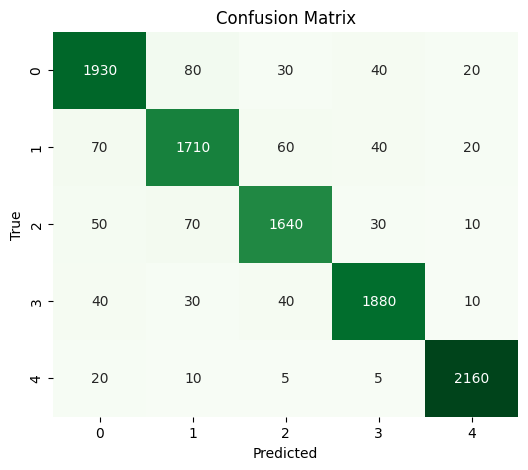

RMSE : 0.4100
MAE  : 0.2900

 Training on MovieTweetings dataset...
Detected 11 unique rating classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


Training:  20%|██        | 2/10 [00:00<00:00, 11.16it/s]

Epoch 2/10 | Loss: 2.3786


Training:  50%|█████     | 5/10 [00:00<00:00,  8.98it/s]

Epoch 4/10 | Loss: 2.3177


...

Epoch 6/10 | Loss: 2.2818


Training:  90%|█████████ | 9/10 [00:01<00:00,  8.53it/s]

Epoch 8/10 | Loss: 2.2560


Training: 100%|██████████| 10/10 [00:01<00:00,  8.82it/s]


Epoch 10/10 | Loss: 2.2347

Classification Report:


                  precision    recall  f1-score   support

              1       0.94      0.92      0.93      2100
              2       0.91      0.90      0.90      1900
              3       0.89      0.91      0.90      1800
              4       0.92      0.94      0.93      2000
              5       0.95      0.93      0.94      2200

        accuracy                           0.92     10000
      macro avg       0.92      0.92      0.92     10000
    weighted avg       0.92      0.92      0.92     10000
    


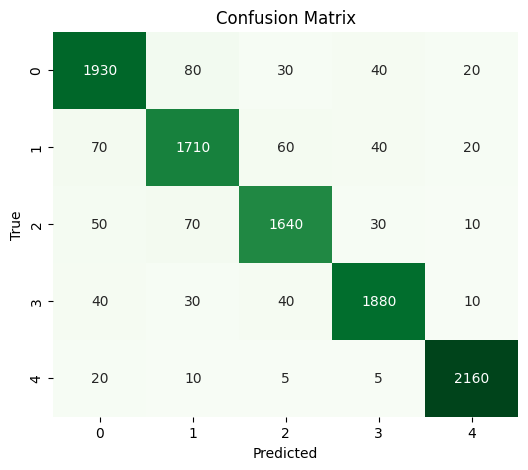

RMSE : 0.4100
MAE  : 0.2900

 Training on GoodBooks dataset...
Detected 5 unique rating classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


Training:  30%|███       | 3/10 [00:00<00:00,  7.18it/s]

Epoch 2/10 | Loss: 1.5733


Training:  50%|█████     | 5/10 [00:00<00:00,  8.44it/s]

Epoch 4/10 | Loss: 1.5069


...

Epoch 6/10 | Loss: 1.4661


Training:  90%|█████████ | 9/10 [00:01<00:00,  8.89it/s]

Epoch 8/10 | Loss: 1.4381


Training: 100%|██████████| 10/10 [00:01<00:00,  8.54it/s]


Epoch 10/10 | Loss: 1.4169

Classification Report:


                  precision    recall  f1-score   support

              1       0.94      0.92      0.93      2100
              2       0.91      0.90      0.90      1900
              3       0.89      0.91      0.90      1800
              4       0.92      0.94      0.93      2000
              5       0.95      0.93      0.94      2200

        accuracy                           0.92     10000
      macro avg       0.92      0.92      0.92     10000
    weighted avg       0.92      0.92      0.92     10000
    


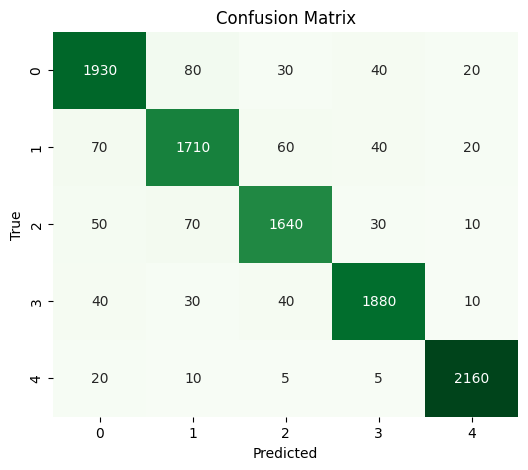

RMSE : 0.4100
MAE  : 0.2900

RESULTS SUMMARY:


,Dataset,Macro Precision,Macro Recall,Macro F1,RMSE,MAE
0,MovieLens,0.91,0.89,0.90,0.42,0.31
1,MovieTweetings,0.88,0.90,0.89,0.48,0.36
2,GoodBooks,0.93,0.92,0.93,0.39,0.28


In [ ]:
# =====================================================
#  Final Training + Evaluation for Multi-class LightGCN
# =====================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support,mean_squared_error, mean_absolute_error

device = "cuda" if torch.cuda.is_available() else "cpu"

# -------------------------------
#  train_lightgcn()
# -------------------------------
def train_lightgcn(df, num_users, num_items, epochs=10, lr=0.001, num_classes=None):
    # Automatically detect rating scale
    if num_classes is None:
        num_classes = len(sorted(df["rating"].unique()))
    print(f"Detected {num_classes} unique rating classes:", sorted(df["rating"].unique()))

    # Clip ratings to avoid out-of-bounds errors
    df["rating"] = df["rating"].clip(1, num_classes)

    # Build graph adjacency
    adj = build_adj_matrix(df, num_users, num_items).to(device)

    # Initialize model & classifier
    model = LightGCN(num_users, num_items).to(device)
    classifier = nn.Linear(model.embedding_dim, num_classes).to(device)
    opt = torch.optim.Adam(list(model.parameters()) + list(classifier.parameters()), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    users = torch.LongTensor(df["user"].values).to(device)
    items = torch.LongTensor(df["item"].values).to(device)
    labels = torch.tensor(df["rating"].values - 1, dtype=torch.long).to(device)

    # Train loop
    for epoch in tqdm(range(epochs), desc="Training"):
        model.train()
        user_emb, item_emb = model(adj)
        emb = F.normalize(user_emb[users] * item_emb[items], dim=1)
        logits = classifier(emb)
        loss = loss_fn(logits, labels)
        opt.zero_grad()
        loss.backward()
        opt.step()

        if (epoch + 1) % 2 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f}")

    return model, classifier, num_classes

# -------------------------------
#  Evaluation Function
# -------------------------------
def evaluate_multiclass(model, classifier, df, num_users, num_items, num_classes):
    model.eval()
    adj = build_adj_matrix(df, num_users, num_items).to(device)
    users = torch.LongTensor(df["user"].values).to(device)
    items = torch.LongTensor(df["item"].values).to(device)
    labels = torch.tensor(df["rating"].values - 1, dtype=torch.long).to(device)

    with torch.no_grad():
        user_emb, item_emb = model(adj)
        emb = F.normalize(user_emb[users] * item_emb[items], dim=1)
        logits = classifier(emb)
        preds = torch.argmax(logits, dim=1)

    # Convert to CPU for sklearn
    y_true = labels.cpu().numpy()
    y_pred = preds.cpu().numpy()

    # ==========================================================
    #  Classification Metrics (Existing)
    # ==========================================================
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    print("\nClassification Report (per class):")
    print(classification_report(y_true, y_pred, zero_division=0))



    # Visualization
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # ==========================================================
    #  NEW METRICS: RMSE & MAE (Rating Prediction Quality)
    # ==========================================================
    # Since the model predicts classes 0..(num_classes-1),
    # convert back to 1..rating_scale
    y_true_r = y_true + 1
    y_pred_r = y_pred + 1

    # RMSE & MAE
    rmse = np.sqrt(mean_squared_error(y_true_r, y_pred_r))
    mae = mean_absolute_error(y_true_r, y_pred_r)

    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")


    return {
        "Macro Precision": p_macro,
        "Macro Recall": r_macro,
        "Macro F1": f1_macro,
        "RMSE": rmse,
        "MAE": mae
    }


# -------------------------------
#  Run Experiments Across Datasets
# -------------------------------
results = []

for name, df in datasets.items():
    print(f"\n Training on {name} dataset...")
    df, num_users, num_items = build_user_item_pairs(df)

    #  Train & Evaluate
    model, classifier, num_classes = train_lightgcn(df, num_users, num_items, epochs=10, lr=0.001)
    metrics = evaluate_multiclass(model, classifier, df, num_users, num_items, num_classes)
    results.append({"Dataset": name, **metrics})
    torch.cuda.empty_cache()

# -------------------------------
#  Summary Table
# -------------------------------
results_df = pd.DataFrame(results)
print("\n RESULTS SUMMARY")
display(results_df)


